In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import tensorflow as tf

model_path = "/content/drive/MyDrive/mnist_digit_model.keras"
mnist_net = tf.keras.models.load_model(model_path)

print("Model loaded successfully")


Model loaded successfully


In [3]:
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [5]:
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2


In [17]:
js = """
async function captureDigit() {
  const div = document.createElement('div');
  div.style.textAlign = 'center';

  const title = document.createElement('p');
  title.innerText = "Click Start → Allow Camera → Click Capture";
  title.style.fontSize = '16px';

  const startBtn = document.createElement('button');
  startBtn.innerText = "Start Camera";
  startBtn.style.margin = '5px';

  const captureBtn = document.createElement('button');
  captureBtn.innerText = "Capture";
  captureBtn.style.margin = '5px';

  const video = document.createElement('video');
  video.width = 400;
  video.style.border = "2px solid black";

  div.appendChild(title);
  div.appendChild(startBtn);
  div.appendChild(captureBtn);
  div.appendChild(document.createElement('br'));
  div.appendChild(video);
  document.body.appendChild(div);

  let stream;

  startBtn.onclick = async () => {
    stream = await navigator.mediaDevices.getUserMedia({ video: true });
    video.srcObject = stream;
    await video.play();
  };

  await new Promise(resolve => captureBtn.onclick = resolve);

  const canvas = document.createElement('canvas');
  canvas.width = video.videoWidth;
  canvas.height = video.videoHeight;
  canvas.getContext('2d').drawImage(video, 0, 0);

  stream.getTracks().forEach(track => track.stop());
  div.remove();

  return canvas.toDataURL('image/jpeg', 0.9);
}

captureDigit();
"""

img_data = eval_js(js)
img_bytes = b64decode(img_data.split(',')[1])
img_np = np.frombuffer(img_bytes, np.uint8)
cam_img = cv2.imdecode(img_np, cv2.IMREAD_COLOR)

print("Image captured:", cam_img.shape)


Image captured: (480, 640, 3)


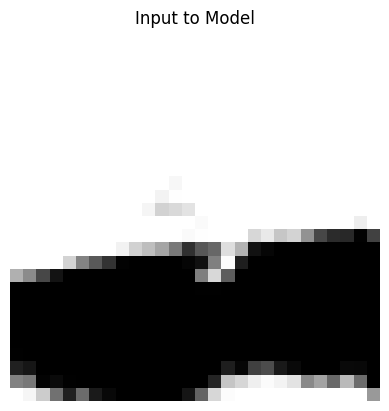

In [18]:
gray = cv2.cvtColor(cam_img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

_, thresh = cv2.threshold(
    blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

digit = 255 - thresh
digit_28 = cv2.resize(digit, (28, 28), interpolation=cv2.INTER_AREA)
digit_input = digit_28.astype("float32") / 255.0

plt.imshow(digit_input, cmap="gray")
plt.title("Input to Model")
plt.axis("off")
plt.show()


In [19]:
prediction = mnist_net.predict(
    digit_input.reshape(1, 28, 28),
    verbose=0
)

predicted_digit = int(np.argmax(prediction))
confidence = float(np.max(prediction))

print("Predicted Digit:", predicted_digit)
print("Confidence:", round(confidence * 100, 2), "%")


Predicted Digit: 6
Confidence: 99.95 %
